# Parameter Space Landscape Comparison

This notebook compares two different parameterization strategies for quantum sensing optimization:

1. **θ, Δθ strategy**: Uses symmetric rotations Ry(θ+Δθ) and Ry(θ-Δθ)
2. **θ₁, θ₂ strategy**: Uses independent rotations Ry(θ₁) and Ry(θ₂)

We'll visualize the loss function landscapes and analyze optimization behavior for both approaches.

In [105]:
# Import required libraries
import jax
import jax.numpy as jnp
from jax import random, jit, grad, vmap
import qutip as qt
import qutip_jax as qtj
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import optax
from functools import partial
import warnings
warnings.filterwarnings('ignore')

In [106]:
gm = 0.03 * 2 * np.pi        # photon-cavity coupling
sigma = 0.1 * gm             # inverse of the pulse width
chi = 0.5 * gm               # dispersive coupling
nlev = 2                     # Number of cavity levels
qlev = 2                     # Number of qubit levels

# Noise parameters
gamma_relax = 0.0001 * 2 * np.pi      # qubit relaxation rate
gamma_dephasing = 0.0001 * 2 * np.pi  # qubit dephasing rate 
gamma_depol = 0.000 * 2 * np.pi       # depolarizing noise rate

# Measurement configuration
tmeas = [-5.0, -2.5, 0, 2.5, 5.0]          # Measurement time points (in units of sigma)
measurements = np.array(tmeas) / sigma       # normalize by sigma

args = {'sigma': sigma}               # arguments for coefficient function

print(f"Real system parameters:")
print(f"  Cavity levels: {nlev}")
print(f"  Photon-cavity coupling (γ): {gm:.6f}")
print(f"  Pulse width inverse (σ): {sigma:.6f}")
print(f"  Dispersive coupling (χ): {chi:.6f}")
print(f"  Noise - Relaxation: {gamma_relax:.6f}")
print(f"  Noise - Dephasing: {gamma_dephasing:.6f}")
print(f"  Measurement times: {measurements}")

Real system parameters:
  Cavity levels: 2
  Photon-cavity coupling (γ): 0.188496
  Pulse width inverse (σ): 0.018850
  Dispersive coupling (χ): 0.094248
  Noise - Relaxation: 0.000628
  Noise - Dephasing: 0.000628
  Measurement times: [-265.25823849 -132.62911924    0.          132.62911924  265.25823849]


In [107]:
# Quantum operators for three-system composite space: input ⊗ resonator ⊗ qubit
with qt.CoreOptions(default_dtype="jax"):
    
    # Identity operators for each subsystem
    Iq = qt.identity(qlev)  # Qubit identity (2×2)
    In = qt.identity(nlev)  # Cavity identity (2×2)
    
    # Creation and annihilation operators for cavity modes
    An = qt.destroy(nlev)   # Cavity annihilation operator
    Acn = qt.create(nlev)   # Cavity creation operator
    
    # Pauli matrices for qubit operations
    Sz = qt.sigmaz()        # Pauli-Z matrix
    Sx = qt.sigmax()        # Pauli-X matrix
    Sy = qt.sigmay()        # Pauli-Y matrix
    Sminus = qt.destroy(qlev)  # Qubit annihilation operator
    
    # Qubit measurement projectors
    P0 = qt.Qobj([[1,0],[0,0]])  # Ground state projector |0⟩⟨0|
    P1 = qt.Qobj([[0,0],[0,1]])  # Excited state projector |1⟩⟨1|

    # Composite system operators for input ⊗ resonator ⊗ qubit space
    # Input cavity operators (first subsystem)
    ain = qt.tensor(An, In, Iq)   # Input photon annihilation
    ainc = ain.dag()              # Input photon creation
    
    # Resonator cavity operators (second subsystem)  
    a = qt.tensor(In, An, Iq)     # Resonator photon annihilation
    ac = a.dag()                  # Resonator photon creation
    
    # Qubit operators in composite space (third subsystem)
    sz1 = qt.tensor(In, In, Sz)   # Qubit Pauli-Z in composite space
    sx1 = qt.tensor(In, In, Sx)   # Qubit Pauli-X in composite space
    sy1 = qt.tensor(In, In, Sy)   # Qubit Pauli-Y in composite space
    sminus1 = qt.tensor(In, In, Sminus)  # Qubit annihilation in composite space
    
    # Qubit measurement projectors in composite space
    p0 = qt.tensor(In, In, P0)    # Ground state measurement
    p1 = qt.tensor(In, In, P1)    # Excited state measurement

In [108]:

# JAX-compatible quantum operations
from jax.scipy.special import erfc

@jax.jit
def ry(rho, theta):
    """Apply Ry rotation to qubit in the three-system composite space"""
    with qt.CoreOptions(default_dtype="jax"):
        Sy_jax = qt.sigmay()
        ry_gate = (-1j * Sy_jax * theta / 2).expm()
        r = qt.tensor(In, In, ry_gate)
        return r * rho * r.dag()

def proj0(rho):
    """Project density matrix onto qubit |0⟩ state"""
    return p0 * rho * p0.dag()

def prob0(rho):
    """Calculate probability of measuring qubit in |0⟩ state"""
    return jnp.real(proj0(rho).tr())

def prob1(rho):
    """Calculate probability of measuring qubit in |1⟩ state"""
    return jnp.real((p1 * rho * p1.dag()).tr())

@jax.jit
def gu(t, **kwargs):  
    """Time-dependent coupling function for input cavity transparency"""
    sigma = kwargs.get("sigma", 0.1)
    dx = sigma * t
    coupling = jnp.sqrt(2*sigma/jnp.sqrt(jnp.pi)*jnp.exp(-dx**2)/erfc(dx))
    return jnp.array(coupling, float)

def create_parameter_grid(param_range=(-np.pi, np.pi), resolution=50):
    """Create 2D parameter grid for landscape visualization"""
    param1 = np.linspace(param_range[0], param_range[1], resolution)
    param2 = np.linspace(param_range[0], param_range[1], resolution)
    P1, P2 = np.meshgrid(param1, param2)
    return P1, P2, param1, param2

In [109]:
# Time-dependent Hamiltonian construction and solver configuration
with qt.CoreOptions(default_dtype="jax"): 
    print("Constructing time-dependent Hamiltonian...")   
    # Time-dependent cavity-cavity coupling Hamiltonian
    Hc = qt.Qobj(1j/2*jnp.sqrt(gm)*(ainc*a - ain*ac))
    
    # Dispersive qubit-resonator interaction Hamiltonian  
    Hq = qt.Qobj(-chi*ac*a*sz1)   
    
    # Complete time-dependent Hamiltonian
    Htot = qt.QobjEvo([Hq, [Hc, gu]], args=args)
    
    # Lindblad interaction operators
    L_int = qt.QobjEvo([ain, gu], args=args) + jnp.sqrt(gm) * a

    # Lindblad noise operators
    lindblad_noise = []
    if gamma_depol != 0.:
        print("Adding depolarizing noise operators")
        L1_depol = jnp.sqrt(gamma_depol/3) * sx1 # σₓ component
        L2_depol = jnp.sqrt(gamma_depol/3) * sy1 # σᵧ component  
        L3_depol = jnp.sqrt(gamma_depol/3) * sz1 # σᵤ component
        lindblad_noise.extend([L1_depol, L2_depol, L3_depol])
        
    if gamma_relax != 0.:
        print("Adding relaxation noise operators")
        L_relax = jnp.sqrt(gamma_relax) * sminus1
        lindblad_noise.append(L_relax)
        
    if gamma_dephasing != 0.:
        print("Adding dephasing noise operators") 
        L_dephasing = jnp.sqrt(gamma_dephasing) * sz1
        lindblad_noise.append(L_dephasing)
    
    # Solver options for different scenarios
    solver_opts = qt.SolverOptions(
        method='diffrax'
    )
    
    # Interaction solver (with input photon coupling)
    solver_interaction = qt.MESolver(
        Htot,
        c_ops=[L_int] + lindblad_noise,  
        options=solver_opts
    )
    
    # No-interaction solver (isolated cavity-qubit system)
    solver_no_interaction = qt.MESolver(
        Hq,  # Only dispersive interaction, no cavity coupling
        c_ops=lindblad_noise,
        options=solver_opts
    )

print("✓ Hamiltonians and solvers configured")
print(f"✓ Noise operators: {len(lindblad_noise)} terms")

Constructing time-dependent Hamiltonian...
Adding relaxation noise operators
Adding dephasing noise operators
✓ Hamiltonians and solvers configured
✓ Noise operators: 2 terms


In [110]:
# Main simulation function for the quantum sensing system
def simulation(args, solver, rho, theta1, theta2, measurements):
    """
    Complete quantum sensing simulation with time evolution
    
    Args:
        args: Dictionary with system parameters
        solver: QuTiP solver (interaction or no-interaction)
        rho: Initial density matrix
        theta1, theta2: Rotation parameters
        measurements: Dictionary of measurement times and outcomes
        
    Returns:
        float: Detection probability for the measurement sequence
    """
    probability_list = []
    # Process each measurement interval sequentially
    for kt in range(len(measurements[:-1])):
        t0, t1 = measurements[kt], measurements[kt+1]
        
        # Step 1: Apply first rotation Ry(θ₁) for state preparation
        rho_after_ry = ry(rho, theta1)
        
        # Step 2: Time evolution under system Hamiltonian H(t)
        evolution_result = solver.run(rho_after_ry, [t0, t1], args=args)
        rho_evolved = evolution_result.states[-1]
        
        # Step 3: Apply second rotation Ry(θ₂) for measurement optimization
        rho_final = ry(rho_evolved, theta2)
        
        # Step 4: Measure qubit in |0⟩ state (ground state probability)
        probability_list.append(prob0(rho_final))
        
        # Step 5: Project onto measurement result for conditional evolution
        # For future extension: conditional on measurement_results[kt]
        rho = proj0(rho_final)  # Currently: always project to |0⟩
        rho = rho / rho.tr()    # Normalize

    # Calculate detection probability: P(at least one |1⟩) = 1 - P(all |0⟩)
    prob_all_ground = jnp.prod(jnp.array(probability_list))
    prob_detection = 1 - prob_all_ground

    return prob_detection


# Create initial ground state for the system
def create_initial_state():
    """Create initial state |100⟩ for input ⊗ resonator ⊗ qubit"""
    with qt.CoreOptions(default_dtype="jax"):
        psi0 = qt.tensor(qt.basis(nlev, 1), qt.basis(nlev, 0), qt.basis(qlev, 0))
        return psi0 * psi0.dag()

# Test the simulation
rho0 = create_initial_state()

# Quick test of the simulation
test_int = simulation(args, solver_interaction, rho0, np.pi/2, -np.pi/2, measurements)
print(f"✓ Test simulation, probability: {test_int:.6f}")
# Test the no-interaction case
test_no_int = simulation(args, solver_no_interaction, rho0, np.pi/2, -np.pi/2, measurements)
print(f"✓ Test no-interaction simulation, probability: {test_no_int:.6f}")

✓ Test simulation, probability: 0.921324
✓ Test no-interaction simulation, probability: 0.326323
✓ Test no-interaction simulation, probability: 0.326323


In [111]:
# Parameterization strategies
def simulation_theta_delta(theta, delta_theta, with_interaction=True):
    """
    Simulation using θ, Δθ parameterization
    Applies: Ry(θ+Δθ) → time evolution → Ry(θ-Δθ)
    """
    theta1 = theta + delta_theta
    theta2 = theta - delta_theta
    
    solver = solver_interaction if with_interaction else solver_no_interaction
    return simulation(args, solver, rho0, theta1, theta2, measurements)

def simulation_theta1_theta2(theta1, theta2, with_interaction=True):
    """
    Simulation using θ₁, θ₂ parameterization
    Applies: Ry(θ₁) → time evolution → Ry(θ₂)
    """
    solver = solver_interaction if with_interaction else solver_no_interaction
    return simulation(args, solver, rho0, theta1, theta2, measurements)

def sensing_contrast_theta_delta(theta, delta_theta):
    """Calculate sensing contrast for θ, Δθ strategy"""
    prob_with = simulation_theta_delta(theta, delta_theta, with_interaction=True)
    prob_without = simulation_theta_delta(theta, delta_theta, with_interaction=False)
    return - prob_with + prob_without

def sensing_contrast_theta1_theta2(theta1, theta2):
    """Calculate sensing contrast for θ₁, θ₂ strategy"""
    prob_with = simulation_theta1_theta2(theta1, theta2, with_interaction=True)
    prob_without = simulation_theta1_theta2(theta1, theta2, with_interaction=False)
    return  - prob_with + prob_without

# Loss functions (negative sensing contrast for minimization)
def loss_theta_delta(params):
    """Loss function for θ, Δθ parameterization"""
    theta, delta_theta = params
    return sensing_contrast_theta_delta(theta, delta_theta)

def loss_theta1_theta2(params):
    """Loss function for θ₁, θ₂ parameterization"""
    theta1, theta2 = params
    return sensing_contrast_theta1_theta2(theta1, theta2)

print("✓ Parameterization strategies implemented")

✓ Parameterization strategies implemented


Computing focused landscape around π/2, -π/2 region...
  Progress: 99.2%
✓ Focused landscape computed!

✓ Focused landscape computed!


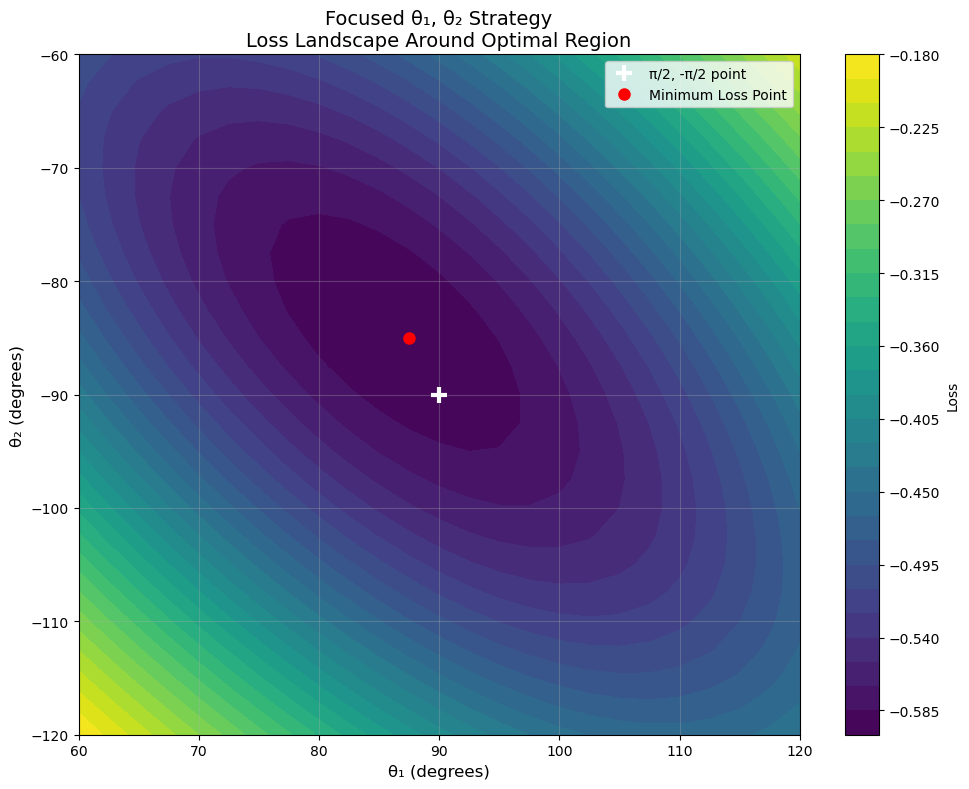


Focused Region Analysis:
Focused optimal: θ₁=87.50°, θ₂=-85.00°, Loss=-0.59873911
Reference point: θ₁=90.0°, θ₂=-90.0°
Landscape variation in focused region: 4.19e-01
Equivalent θ, Δθ: θ=1.25°, Δθ=86.25°


In [112]:
# Focused view around the optimal region (π/2, -π/2)
print("Computing focused landscape around π/2, -π/2 region...")

# Define focused parameter range around π/2, -π/2
focus_center_theta1 = np.pi/2    # 90 degrees
focus_center_theta2 = -np.pi/2   # -90 degrees
focus_range = np.pi/6            # ±45 degrees around center

# Create focused parameter grid
theta1_focus_range = (focus_center_theta1 - focus_range, focus_center_theta1 + focus_range)
theta2_focus_range = (focus_center_theta2 - focus_range, focus_center_theta2 + focus_range)

resolution_focus = 25  # Higher resolution for focused view
theta1_focus = np.linspace(theta1_focus_range[0], theta1_focus_range[1], resolution_focus)
theta2_focus = np.linspace(theta2_focus_range[0], theta2_focus_range[1], resolution_focus)
P1_focus, P2_focus = np.meshgrid(theta1_focus, theta2_focus)

# Compute focused landscape for θ₁, θ₂ strategy (most relevant)
Z_focus = np.zeros_like(P1_focus)
for i in range(resolution_focus):
    for j in range(resolution_focus):
        if (i * resolution_focus + j) % 10 == 0:
            print(f"  Progress: {((i * resolution_focus + j) / (resolution_focus**2) * 100):.1f}%", end='\r')
        Z_focus[i, j] = loss_theta1_theta2([P1_focus[i, j], P2_focus[i, j]])

print("\n✓ Focused landscape computed!")

# Visualize focused region
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Convert to degrees for visualization
P1_focus_deg = np.degrees(P1_focus)
P2_focus_deg = np.degrees(P2_focus)

# Create contour plot with higher detail
im = ax.contourf(P1_focus_deg, P2_focus_deg, Z_focus, levels=30, cmap='viridis')
ax.set_xlabel('θ₁ (degrees)', fontsize=12)
ax.set_ylabel('θ₂ (degrees)', fontsize=12)
ax.set_title('Focused θ₁, θ₂ Strategy\nLoss Landscape Around Optimal Region', fontsize=14)
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, label='Loss')

# Find and mark the minimum in the focused region
min_idx_focus = np.unravel_index(np.argmin(Z_focus), Z_focus.shape)
min_theta1_focus = P1_focus[min_idx_focus]
min_theta2_focus = P2_focus[min_idx_focus]
min_loss_focus = Z_focus[min_idx_focus]

# Mark the theoretical center point (π/2, -π/2)
ax.plot(np.degrees(focus_center_theta1), np.degrees(focus_center_theta2), 
        'w+', markersize=12, markeredgewidth=3, label='π/2, -π/2 point')

# Mark the minimum point in the focused region
ax.plot(np.degrees(min_theta1_focus), np.degrees(min_theta2_focus), 
        'ro', markersize=8, label='Minimum Loss Point')

ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"\nFocused Region Analysis:")
print(f"Focused optimal: θ₁={np.degrees(min_theta1_focus):.2f}°, θ₂={np.degrees(min_theta2_focus):.2f}°, Loss={min_loss_focus:.8f}")
print(f"Reference point: θ₁=90.0°, θ₂=-90.0°")
print(f"Landscape variation in focused region: {Z_focus.max() - Z_focus.min():.2e}")

# Compare with equivalent θ, Δθ parameterization
equiv_theta = (min_theta1_focus + min_theta2_focus) / 2
equiv_delta = (min_theta1_focus - min_theta2_focus) / 2
print(f"Equivalent θ, Δθ: θ={np.degrees(equiv_theta):.2f}°, Δθ={np.degrees(equiv_delta):.2f}°")

Computing focused θ, Δθ landscape around 0, π/2 region...
  Progress: 99.2%
✓ Focused θ, Δθ landscape computed!

✓ Focused θ, Δθ landscape computed!


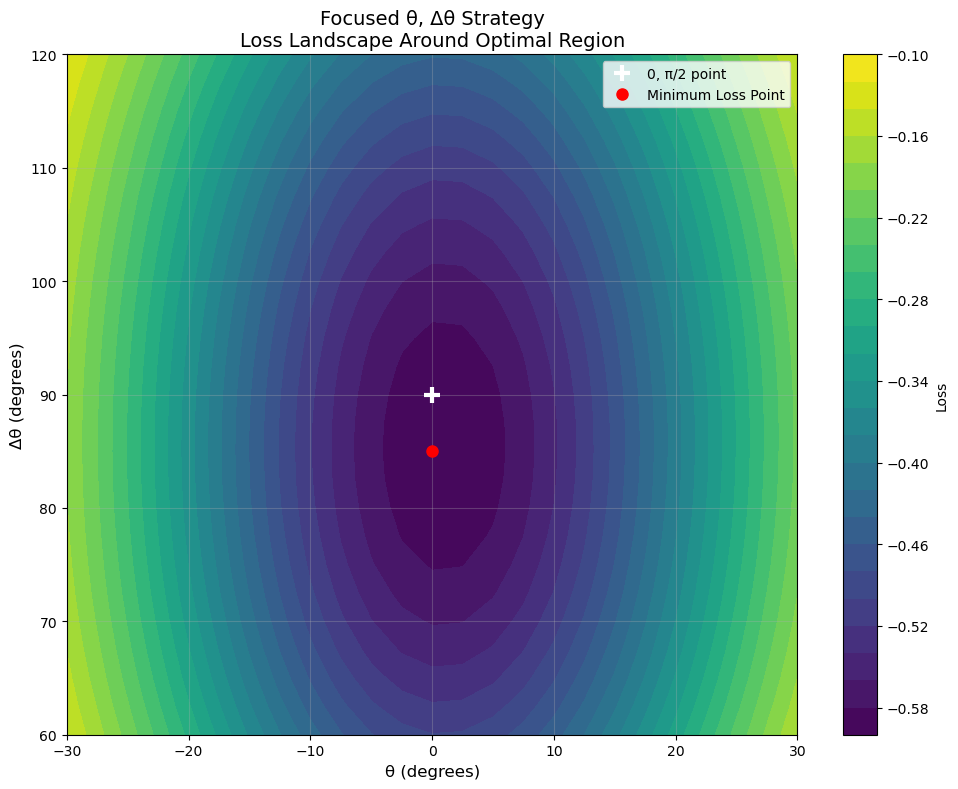


Focused θ, Δθ Region Analysis:
Focused optimal: θ=0.00°, Δθ=85.00°, Loss=-0.59821676
Reference point: θ=0.0°, Δθ=90.0°
Landscape variation in focused region: 4.78e-01
Equivalent θ₁, θ₂: θ₁=85.00°, θ₂=-85.00°
Verification: θ₁, θ₂ loss = -0.59821676 (difference: 0.00e+00)
Verification: θ₁, θ₂ loss = -0.59821676 (difference: 0.00e+00)


In [113]:
# Focused view for θ, Δθ strategy around the optimal region (0, π/2)
print("Computing focused θ, Δθ landscape around 0, π/2 region...")

# Define focused parameter range around 0, π/2
focus_center_theta = 0.0         # 0 degrees
focus_center_delta = np.pi/2     # 90 degrees
focus_range_theta = np.pi/6      # ±60 degrees around theta center
focus_range_delta = np.pi/6      # ±45 degrees around delta center

# Create focused parameter grid for θ, Δθ
theta_focus_range = (focus_center_theta - focus_range_theta, focus_center_theta + focus_range_theta)
delta_focus_range = (focus_center_delta - focus_range_delta, focus_center_delta + focus_range_delta)

resolution_focus_td = 25  # Higher resolution for focused view
theta_focus_td = np.linspace(theta_focus_range[0], theta_focus_range[1], resolution_focus_td)
delta_focus_td = np.linspace(delta_focus_range[0], delta_focus_range[1], resolution_focus_td)
P_theta_focus, P_delta_focus = np.meshgrid(theta_focus_td, delta_focus_td)

# Compute focused landscape for θ, Δθ strategy
Z_focus_td = np.zeros_like(P_theta_focus)
for i in range(resolution_focus_td):
    for j in range(resolution_focus_td):
        if (i * resolution_focus_td + j) % 10 == 0:
            print(f"  Progress: {((i * resolution_focus_td + j) / (resolution_focus_td**2) * 100):.1f}%", end='\r')
        Z_focus_td[i, j] = loss_theta_delta([P_theta_focus[i, j], P_delta_focus[i, j]])

print("\n✓ Focused θ, Δθ landscape computed!")

# Visualize focused region for θ, Δθ strategy
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Convert to degrees for visualization
P_theta_focus_deg = np.degrees(P_theta_focus)
P_delta_focus_deg = np.degrees(P_delta_focus)

# Create contour plot with higher detail
im = ax.contourf(P_theta_focus_deg, P_delta_focus_deg, Z_focus_td, levels=30, cmap='viridis')
ax.set_xlabel('θ (degrees)', fontsize=12)
ax.set_ylabel('Δθ (degrees)', fontsize=12)
ax.set_title('Focused θ, Δθ Strategy\nLoss Landscape Around Optimal Region', fontsize=14)
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, label='Loss')

# Find and mark the minimum in the focused region
min_idx_focus_td = np.unravel_index(np.argmin(Z_focus_td), Z_focus_td.shape)
min_theta_focus_td = P_theta_focus[min_idx_focus_td]
min_delta_focus_td = P_delta_focus[min_idx_focus_td]
min_loss_focus_td = Z_focus_td[min_idx_focus_td]

# Mark the theoretical center point (0, π/2)
ax.plot(np.degrees(focus_center_theta), np.degrees(focus_center_delta), 
        'w+', markersize=12, markeredgewidth=3, label='0, π/2 point')

# Mark the minimum point in the focused region
ax.plot(np.degrees(min_theta_focus_td), np.degrees(min_delta_focus_td),
        'ro', markersize=8, label='Minimum Loss Point')

ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"\nFocused θ, Δθ Region Analysis:")
print(f"Focused optimal: θ={np.degrees(min_theta_focus_td):.2f}°, Δθ={np.degrees(min_delta_focus_td):.2f}°, Loss={min_loss_focus_td:.8f}")
print(f"Reference point: θ=0.0°, Δθ=90.0°")
print(f"Landscape variation in focused region: {Z_focus_td.max() - Z_focus_td.min():.2e}")

# Compare with equivalent θ₁, θ₂ parameterization
equiv_theta1_td = min_theta_focus_td + min_delta_focus_td
equiv_theta2_td = min_theta_focus_td - min_delta_focus_td
print(f"Equivalent θ₁, θ₂: θ₁={np.degrees(equiv_theta1_td):.2f}°, θ₂={np.degrees(equiv_theta2_td):.2f}°")

# Verify equivalence by computing the loss with θ₁, θ₂ parameterization
verify_loss = loss_theta1_theta2([equiv_theta1_td, equiv_theta2_td])
print(f"Verification: θ₁, θ₂ loss = {verify_loss:.8f} (difference: {abs(min_loss_focus_td - verify_loss):.2e})")